# Coffee cupping score analysis

I use the arabica dataset provided in https://github.com/jldbc/coffee-quality-database/tree/master/data to learn more about:
 
 - The distribution of the Total cup score

 - The features that look promising for predicting the cup score (ignoring the sensory features).
 - Cleaning the dataset for further training.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

Load the data:

In [2]:
URL = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"

coffee_df = pd.read_csv(URL)
coffee_df = coffee_df.drop(columns=["Unnamed: 0"])
coffee_df.to_csv("../data/coffee_data.csv")
coffee_df.info()
coffee_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Species                1311 non-null   object 
 1   Owner                  1304 non-null   object 
 2   Country.of.Origin      1310 non-null   object 
 3   Farm.Name              955 non-null    object 
 4   Lot.Number             270 non-null    object 
 5   Mill                   1001 non-null   object 
 6   ICO.Number             1163 non-null   object 
 7   Company                1102 non-null   object 
 8   Altitude               1088 non-null   object 
 9   Region                 1254 non-null   object 
 10  Producer               1081 non-null   object 
 11  Number.of.Bags         1311 non-null   int64  
 12  Bag.Weight             1311 non-null   object 
 13  In.Country.Partner     1311 non-null   object 
 14  Harvest.Year           1264 non-null   object 
 15  Grad

,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


## Cup score distribution

count    1311.000000
mean       82.115927
std         3.515761
min         0.000000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: Total.Cup.Points, dtype: float64


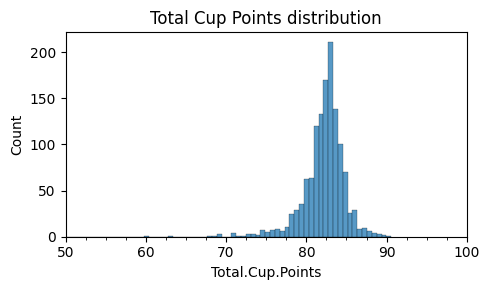

In [3]:
target = "Total.Cup.Points"
print(coffee_df[target].describe())

fig, ax1 = plt.subplots(figsize=(5, 3))
sns.histplot(coffee_df[target], bins=150)
ax1.set_title("Total Cup Points distribution")
ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
plt.xlim(50,100)
plt.tight_layout()
plt.show()

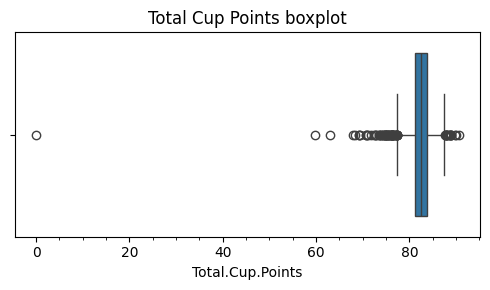

In [6]:
fig, ax1 = plt.subplots(figsize=(5,3))
sns.boxplot(x=coffee_df[target])
ax1.set_title("Total Cup Points boxplot")
ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
plt.tight_layout()
plt.show()

Most of the cup scores are between 80 and 85 and there is a suspicious value at 0.

In [7]:
# Inspect the suspicious data
coffee_df[coffee_df[target] < 10][[target, "Country.of.Origin", "Variety", "Processing.Method", "Aroma", "Flavor"]]

,Total.Cup.Points,Country.of.Origin,Variety,Processing.Method,Aroma,Flavor
1310,0.0,Honduras,Caturra,NaN,0.0,0.0


It is most likely a data entry error, so we can drop this data before modeling.

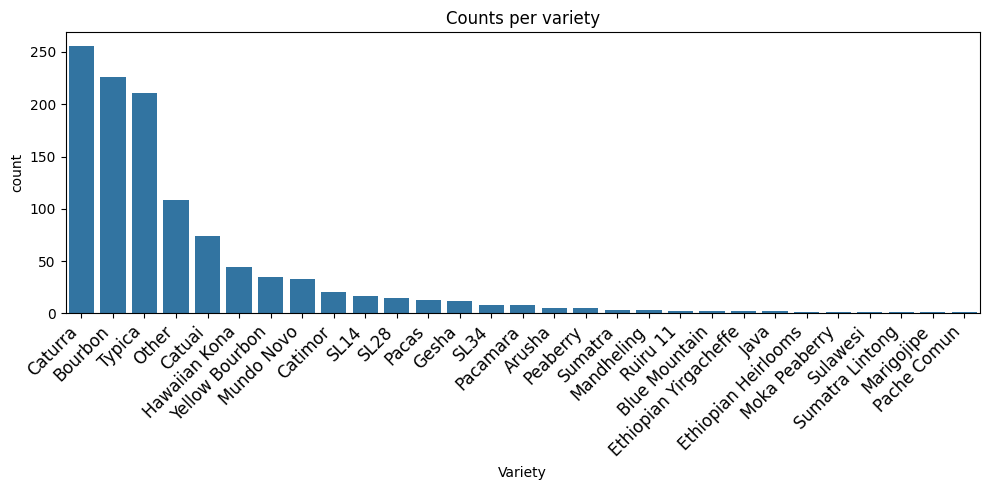

In [20]:


fig, ax1 = plt.subplots(figsize=(10, 5))
sns.countplot(data=coffee_df, x="Variety", order=coffee_df["Variety"].value_counts().index,
    ax=ax1)
ax1.set_title("Counts per variety")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()



## Country of origin

Countries with the largest coffee samples within the dataset:

In [8]:
country_stats = (
    coffee_df.groupby("Country.of.Origin")[target]
      .agg(["count", "mean", "std"])
      .sort_values("count", ascending=False)
)
country_stats.head(15)

,count,mean,std
Country.of.Origin,,,
Mexico,236,80.890085,2.742413
Colombia,183,83.106557,1.413273
Guatemala,181,81.846575,2.885169
Brazil,132,82.405909,2.132902
Taiwan,75,82.001333,1.771503
United States (Hawaii),73,81.820411,2.989757
Honduras,53,79.357547,11.654957
Costa Rica,51,82.789020,2.382883
Ethiopia,44,85.484091,2.337354


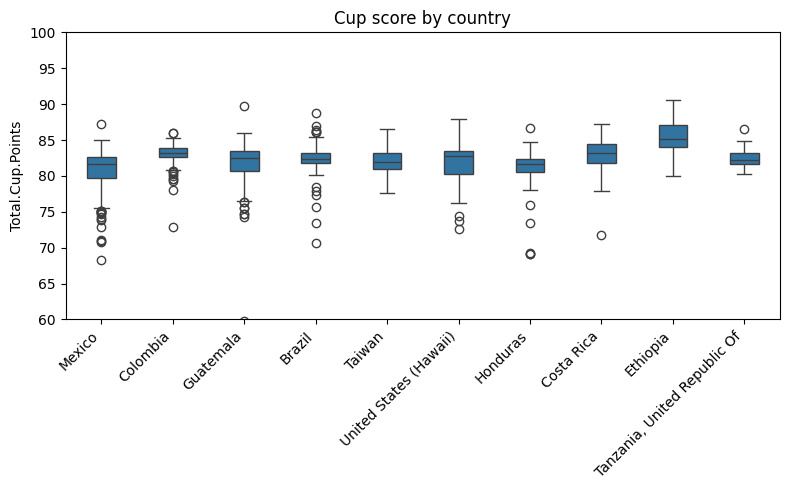

In [9]:
top_countries = country_stats.head(10).index

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=coffee_df[coffee_df["Country.of.Origin"].isin(top_countries)],
    x="Country.of.Origin", 
    y=target, 
    order=top_countries,
    width=0.4
)
plt.xticks(rotation=45, ha="right")
plt.xlabel(None)
plt.ylim(60,100)
plt.title("Cup score by country")
plt.tight_layout()
plt.show()

## Altitude vs cup score

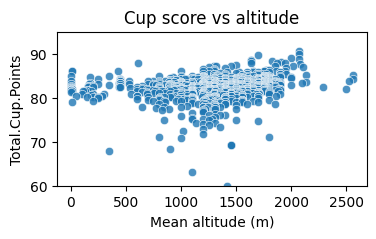

There are n=1070 data points with a correlation = 0.141


In [ ]:
alt = coffee_df[["altitude_mean_meters", target]].dropna()
# filtering absurd values 
alt = alt[(alt["altitude_mean_meters"] > 0)& (alt["altitude_mean_meters"] < 3000)]

plt.figure(figsize=(4, 2))
sns.scatterplot(data=alt, x="altitude_mean_meters", y=target, alpha=0.8)
plt.xlabel("Mean altitude (m)")
plt.ylim(60,95)
plt.title("Cup score vs altitude")
plt.show()

print(f"There are n={len(alt)} data points with a correlation = {alt.corr().iloc[0,1]:.3f}")

## Total cup score

The total cup score is obtained by suming the 10 sensory sub-scores.

In [11]:
sensory = ["Aroma", "Flavor", "Aftertaste", "Acidity", "Body",
           "Balance", "Uniformity", "Clean.Cup", "Sweetness", "Cupper.Points"]

computed_total_score = coffee_df[sensory].sum(axis=1)
diff = (computed_total_score - coffee_df[target]).abs()
print(f"Maximum absolute difference: {diff.max():.3f}")


Maximum absolute difference: 0.500


## Cleaning the dataset and selecting features

We will predict the cup score based on the non-sensory features only.

In [6]:
coffee_df = coffee_df[coffee_df[target] >=10 ].reset_index(drop=True)

#Exclude sensory  features
coffee_df = coffee_df.drop(columns=sensory)

info = pd.DataFrame({
    "dtype": coffee_df.dtypes,
    "n_missing": coffee_df.isna().sum(),
    "pct_missing": (coffee_df.isna().mean()*100).round(1),
    "n_unique": coffee_df.nunique(),
})
info.sort_values("n_unique", ascending = False)


,dtype,n_missing,pct_missing,n_unique
ICO.Number,object,148,11.3,840
Producer,object,230,17.6,675
Grading.Date,object,0,0.0,558
Expiration,object,0,0.0,557
Farm.Name,object,356,27.2,557
Mill,object,310,23.7,447
Altitude,object,223,17.0,383
Region,object,57,4.4,343
Owner.1,object,7,0.5,309
Owner,object,7,0.5,305


In [7]:
top_unique = info.sort_values("n_unique", ascending = False).head(12).index.tolist()
# Exclude unique identifiers
coffee_df = coffee_df.drop(columns=top_unique)
info = info.drop(top_unique)
info.sort_values("n_unique", ascending = False)

,dtype,n_missing,pct_missing,n_unique
altitude_mean_meters,float64,227,17.3,201
altitude_high_meters,float64,227,17.3,188
altitude_low_meters,float64,227,17.3,188
Total.Cup.Points,float64,0,0.0,177
Number.of.Bags,int64,0,0.0,130
Bag.Weight,object,0,0.0,56
Harvest.Year,object,47,3.6,46
Category.Two.Defects,int64,0,0.0,38
Country.of.Origin,object,1,0.1,36
Certification.Address,object,0,0.0,30


In [8]:
redundant_features = ["altitude_high_meters", "altitude_low_meters","Bag.Weight","Harvest.Year",
                      "Certification.Address","In.Country.Partner","Certification.Contact","Certification.Body",
                      "unit_of_measurement","Species", "Country.of.Origin", "Number.of.Bags"]

#Exclude redundant features
coffee_df = coffee_df.drop(columns=redundant_features)
#Exclude coffee data with altitude_mean_meters > 3000 m
coffee_df = coffee_df[coffee_df["altitude_mean_meters"] < 3000]

coffee_df.to_csv("../data/cleaned_coffee_data.csv", index=False)
info = info.drop(redundant_features)
info.sort_values("pct_missing", ascending = False)


,dtype,n_missing,pct_missing,n_unique
Color,object,267,20.4,3
altitude_mean_meters,float64,227,17.3,201
Variety,object,201,15.3,29
Processing.Method,object,151,11.5,5
Quakers,float64,1,0.1,11
Total.Cup.Points,float64,0,0.0,177
Moisture,float64,0,0.0,23
Category.One.Defects,int64,0,0.0,16
Category.Two.Defects,int64,0,0.0,38


In [9]:
numerical_features = ["altitude_mean_meters","Quakers", "Moisture","Category.One.Defects", "Category.Two.Defects"]
coffee_df[numerical_features].corrwith(coffee_df["Total.Cup.Points"])

altitude_mean_meters    0.200671
Quakers                 0.025735
Moisture               -0.164341
Category.One.Defects   -0.134988
Category.Two.Defects   -0.266392
dtype: float64

The coffe cup score shows a weak positive correlation with altitude, indicating that coffees growing at higher elevation tend to receive slightly higher cup scores. Addittionally, the Category.Two.Defects exhibits the strongest negative correlation with cup score, which is expected since an increase in the number of defects generally leads to lower coffee quality.